In [1]:
import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta


from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    KFold,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

import xgboost as xgb
import lightgbm as lgb

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.impute import SimpleImputer

import holidays

def reduce_memory(df):
    """Downcast numeric types to save RAM"""
    for col in df.columns:
        if df[col].dtype == "float64":
            df[col] = df[col].astype("float32")
        elif df[col].dtype == "int64":
            df[col] = df[col].astype("int32")
    return df

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
import kagglehub
import shutil
import os


temp_path = kagglehub.competition_download('walmart-recruiting-store-sales-forecasting')
print("Downloaded temporarily to:", temp_path)

drive_destination = '/content/drive/My Drive/walmart_competition_data'

if not os.path.exists(drive_destination):
    shutil.move(temp_path, drive_destination)
    print("Files successfully moved to your Google Drive at:", drive_destination)
else:
    print("Folder already exists in your Google Drive!")

100%|██████████| 2.70M/2.70M [00:00<00:00, 147MB/s]

Extracting files...
Downloaded temporarily to: /root/.cache/kagglehub/competitions/walmart-recruiting-store-sales-forecasting
Files successfully moved to your Google Drive at: /content/drive/My Drive/walmart_competition_data


In [5]:
import zipfile

with zipfile.ZipFile("/content/drive/My Drive/walmart_competition_data/train.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(pwd=b"train.csv")


with zipfile.ZipFile("/content/drive/My Drive/walmart_competition_data/test.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(pwd=b"test.csv")


with zipfile.ZipFile("/content/drive/My Drive/walmart_competition_data/features.csv.zip", 'r') as zip_ref:
    zip_ref.extractall(pwd=b"features.csv")



In [16]:
df_train = pd.read_csv("/content/drive/My Drive/walmart_competition_data/train.csv")
df_test = pd.read_csv("/content/drive/My Drive/walmart_competition_data/test.csv")
df_features = pd.read_csv("/content/drive/My Drive/walmart_competition_data/features.csv")
df_stores = pd.read_csv("/content/drive/My Drive/walmart_competition_data/stores.csv")

In [17]:
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [18]:
df_test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [19]:
df_features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [20]:

df_train_tmp = pd.merge(df_train, df_stores, on='Store', how='left')
df_train_tmp = pd.merge(df_train_tmp, df_features, on=['Store', 'Date', 'IsHoliday'], how='left')

df_train_tmp['Date'] = pd.to_datetime(df_train_tmp['Date'])

df_train = df_train_tmp.copy()


In [35]:
df_train.shape

(421570, 18)

In [21]:
df_train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [22]:
null = df_train.isna().mean()
print(null)

Store           0.000000
Dept            0.000000
Date            0.000000
Weekly_Sales    0.000000
IsHoliday       0.000000
Type            0.000000
Size            0.000000
Temperature     0.000000
Fuel_Price      0.000000
MarkDown1       0.642572
MarkDown2       0.736110
MarkDown3       0.674808
MarkDown4       0.679847
MarkDown5       0.640790
CPI             0.000000
Unemployment    0.000000
dtype: float64


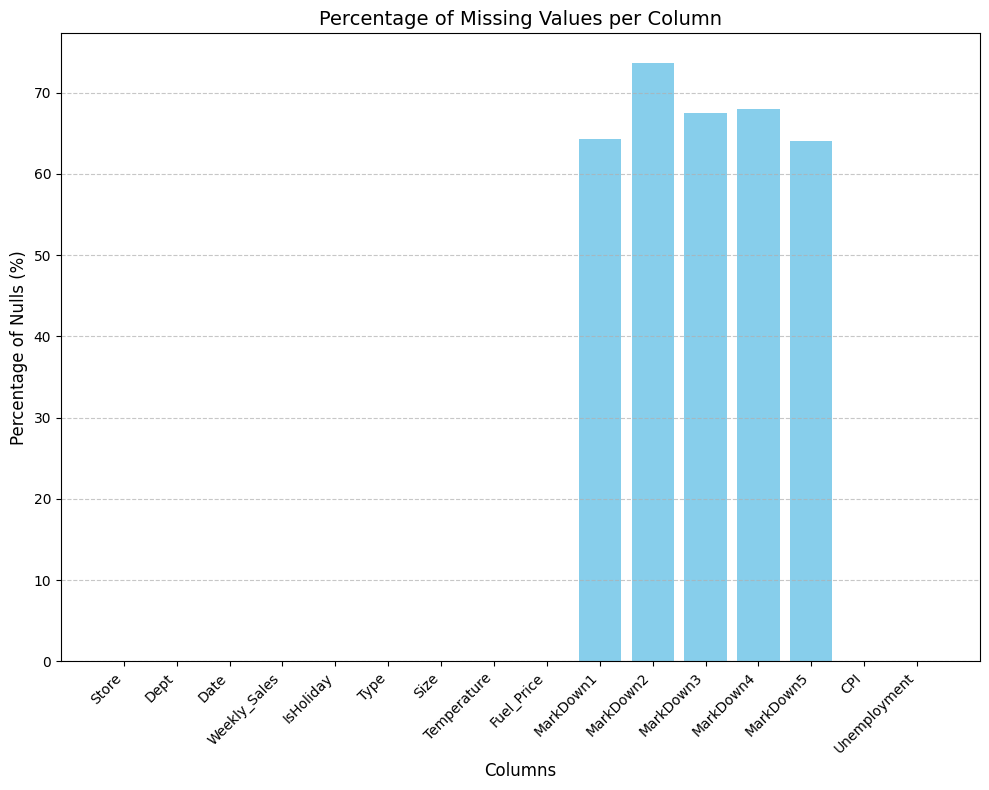

In [24]:
import matplotlib.pyplot as plt

null_percentages = df_train.isnull().mean() * 100

plt.figure(figsize=(10, 8))

plt.bar(null_percentages.index, null_percentages.values, color="skyblue")

plt.title("Percentage of Missing Values per Column", fontsize=14)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Percentage of Nulls (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

In [38]:
import pandas as pd

# Create unique sets of Store-Dept pairs for train and test
train_pairs = set(zip(df_train['Store'], df_train['Dept']))
test_pairs = set(zip(df_test['Store'], df_test['Dept']))

# Find pairs in test that are NOT in train
missing_in_train = test_pairs - train_pairs
missing_in_test = train_pairs - test_pairs

# Print the results
print(f"Total unique Store-Dept pairs in Train: {len(train_pairs)}")
print(f"Total unique Store-Dept pairs in Test: {len(test_pairs)}")
print(f"Number of Store-Dept pairs in Test but not in Train: {len(missing_in_train)}")
print("\n", len(missing_in_test))
if len(missing_in_train) > 0:
    print("\nAll missing pairs (Store, Dept):")
    display(list(missing_in_train))

print("\n", len(missing_in_train))
if len(missing_in_test) > 0:
    print("\nAll missing pairs (Store, Dept):")
    display(list(missing_in_test))


Total unique Store-Dept pairs in Train: 3331
Total unique Store-Dept pairs in Test: 3169
Number of Store-Dept pairs in Test but not in Train: 11

 173

All missing pairs (Store, Dept):


[(18, 43),
 (24, 43),
 (36, 30),
 (37, 29),
 (25, 99),
 (9, 99),
 (34, 39),
 (45, 39),
 (42, 30),
 (10, 99),
 (5, 99)]


 11

All missing pairs (Store, Dept):


[(33, 36),
 (25, 96),
 (2, 39),
 (30, 55),
 (36, 71),
 (24, 51),
 (11, 51),
 (7, 99),
 (35, 51),
 (27, 77),
 (3, 77),
 (39, 51),
 (22, 99),
 (11, 78),
 (26, 78),
 (40, 77),
 (16, 77),
 (15, 78),
 (34, 58),
 (42, 41),
 (41, 51),
 (17, 51),
 (28, 51),
 (19, 48),
 (1, 51),
 (17, 78),
 (28, 78),
 (29, 43),
 (21, 48),
 (12, 45),
 (32, 78),
 (42, 34),
 (27, 45),
 (6, 77),
 (30, 41),
 (25, 45),
 (34, 78),
 (45, 78),
 (5, 78),
 (45, 96),
 (29, 45),
 (21, 96),
 (33, 6),
 (20, 51),
 (18, 51),
 (21, 50),
 (7, 51),
 (36, 41),
 (33, 24),
 (41, 37),
 (30, 34),
 (33, 33),
 (7, 78),
 (18, 78),
 (9, 51),
 (11, 48),
 (22, 78),
 (12, 77),
 (23, 77),
 (3, 83),
 (15, 48),
 (13, 51),
 (9, 78),
 (36, 34),
 (43, 27),
 (13, 78),
 (35, 78),
 (25, 77),
 (33, 35),
 (44, 99),
 (19, 45),
 (39, 78),
 (29, 77),
 (10, 51),
 (11, 50),
 (32, 48),
 (26, 50),
 (21, 45),
 (41, 78),
 (36, 36),
 (1, 78),
 (15, 77),
 (26, 77),
 (27, 51),
 (3, 51),
 (3, 78),
 (14, 78),
 (4, 77),
 (15, 43),
 (18, 39),
 (29, 51),
 (16, 51),
 (40

Frequency of actual time gaps found:
diff_days
7.0      412792
14.0       2346
21.0        862
28.0        517
35.0        338
          ...  
658.0         1
672.0         1
707.0         1
791.0         1
882.0         1
Name: count, Length: 80, dtype: int64


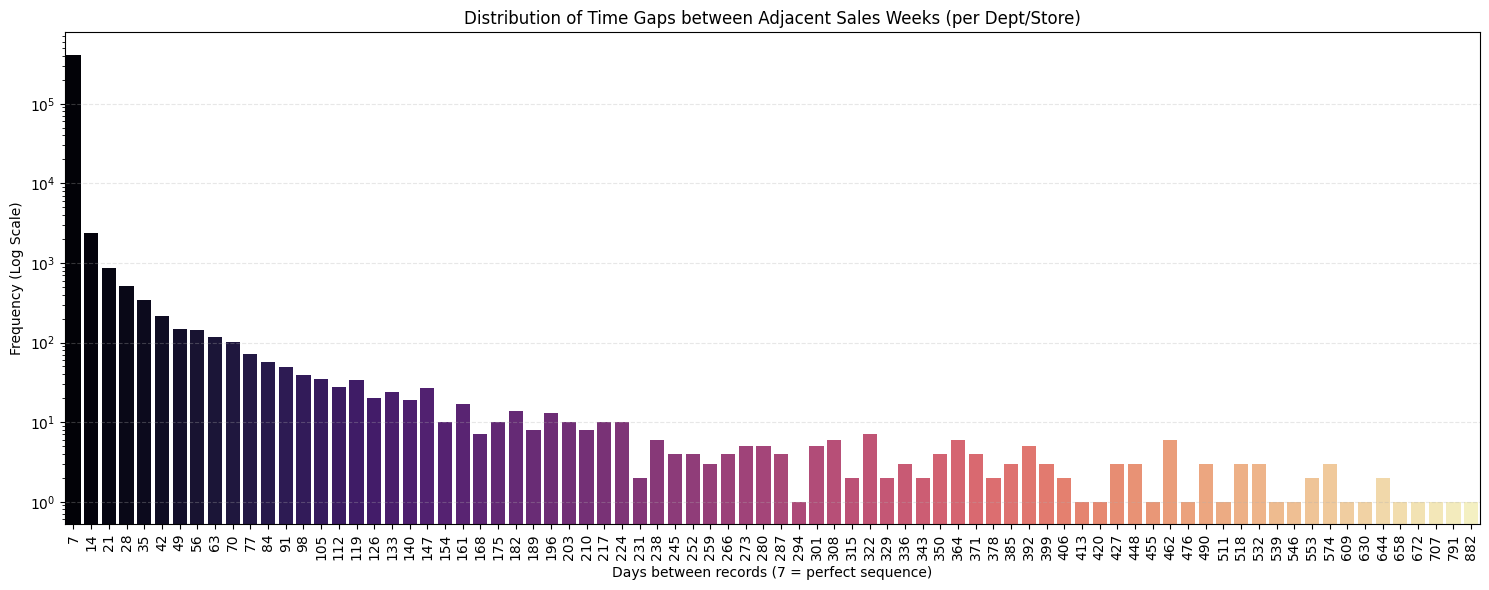

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

df_train['Date'] = pd.to_datetime(df_train['Date'])
df_train = df_train.sort_values(['Store', 'Dept', 'Date'])

df_train['diff_days'] = df_train.groupby(['Store', 'Dept'])['Date'].diff().dt.days

diff_counts = df_train['diff_days'].value_counts().sort_index()

plot_data = diff_counts[diff_counts > 0]

print("Frequency of actual time gaps found:")
print(plot_data)

plt.figure(figsize=(15, 6))
sns.barplot(x=plot_data.index.astype(int), y=plot_data.values, palette='magma')

plt.yscale('log')
plt.title('Distribution of Time Gaps between Adjacent Sales Weeks (per Dept/Store)')
plt.xlabel('Days between records (7 = perfect sequence)')
plt.ylabel('Frequency (Log Scale)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

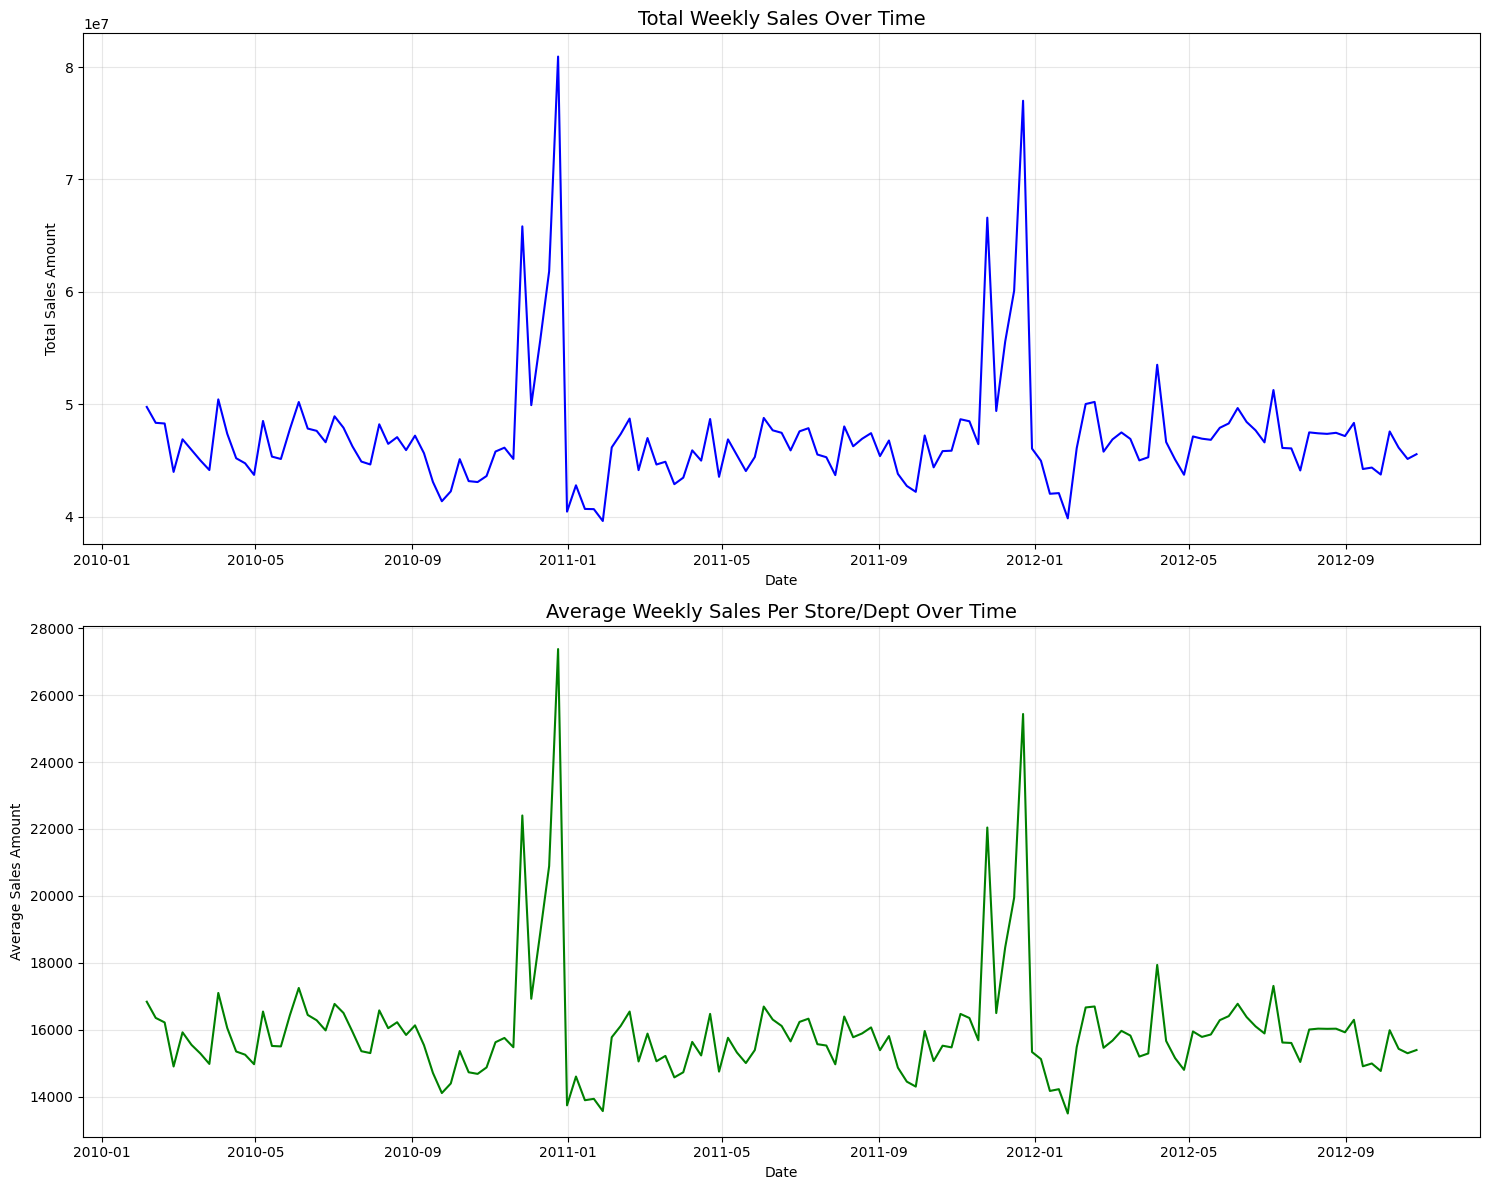

In [41]:
time_series_df = df_train.groupby('Date')['Weekly_Sales'].agg(['sum', 'mean']).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

sns.lineplot(data=time_series_df, x='Date', y='sum', ax=axes[0], color='blue')
axes[0].set_title('Total Weekly Sales Over Time', fontsize=14)
axes[0].set_ylabel('Total Sales Amount')
axes[0].grid(True, alpha=0.3)

sns.lineplot(data=time_series_df, x='Date', y='mean', ax=axes[1], color='green')
axes[1].set_title('Average Weekly Sales Per Store/Dept Over Time', fontsize=14)
axes[1].set_ylabel('Average Sales Amount')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

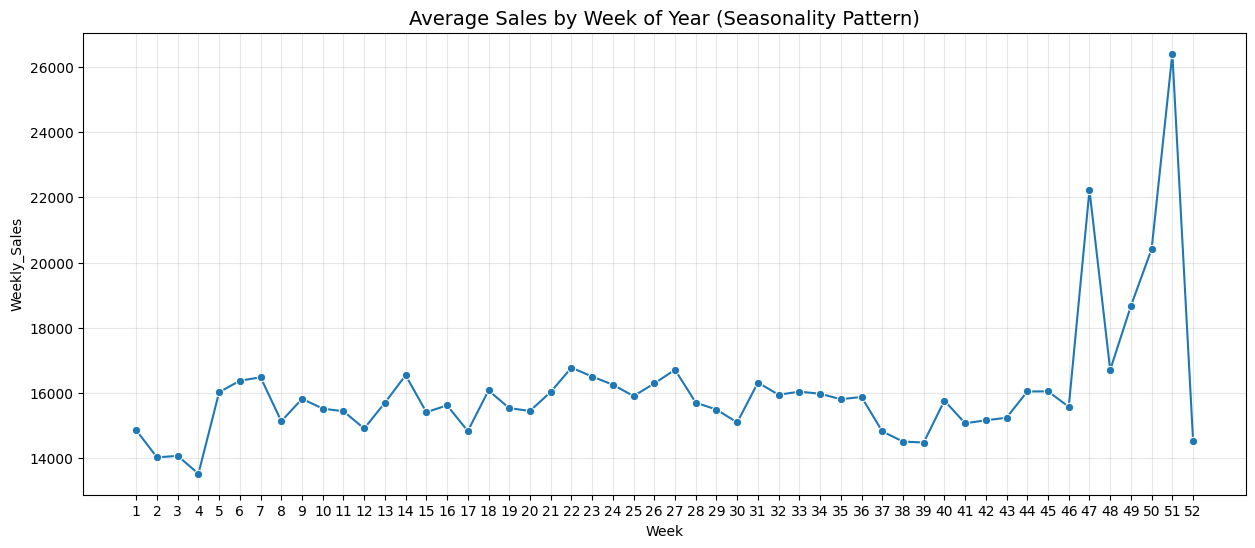

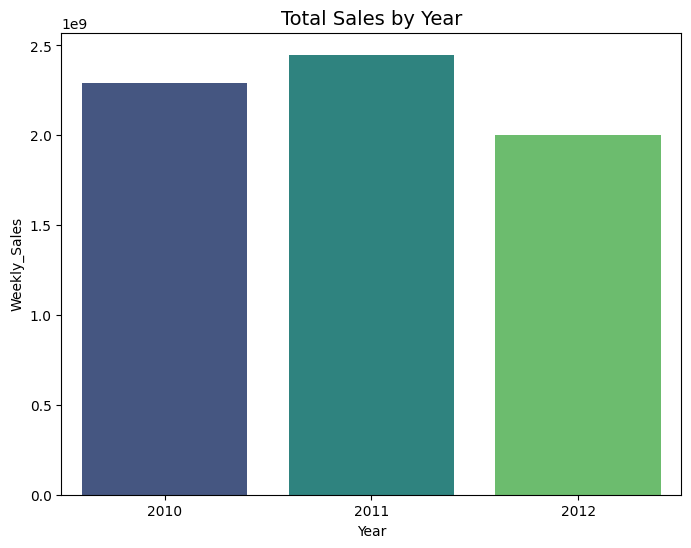

In [43]:

weekly_agg = df_train.groupby('Week')['Weekly_Sales'].mean().reset_index()
plt.figure(figsize=(15, 6))
sns.lineplot(data=weekly_agg, x='Week', y='Weekly_Sales', marker='o')
plt.title('Average Sales by Week of Year (Seasonality Pattern)', fontsize=14)
plt.xticks(range(1, 53))
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(data=df_train, x='Year', y='Weekly_Sales', estimator=sum, ci=None, palette='viridis')
plt.title('Total Sales by Year', fontsize=14)
plt.show()

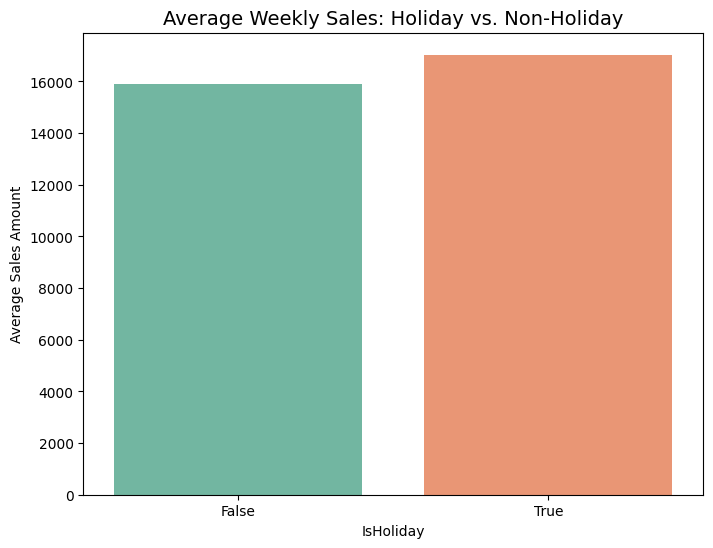

In [44]:
# 1. Holiday vs Non-Holiday Average Sales
holiday_comparison = df_train.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=holiday_comparison, x='IsHoliday', y='Weekly_Sales', palette='Set2')
plt.title('Average Weekly Sales: Holiday vs. Non-Holiday', fontsize=14)
plt.ylabel('Average Sales Amount')
plt.show()

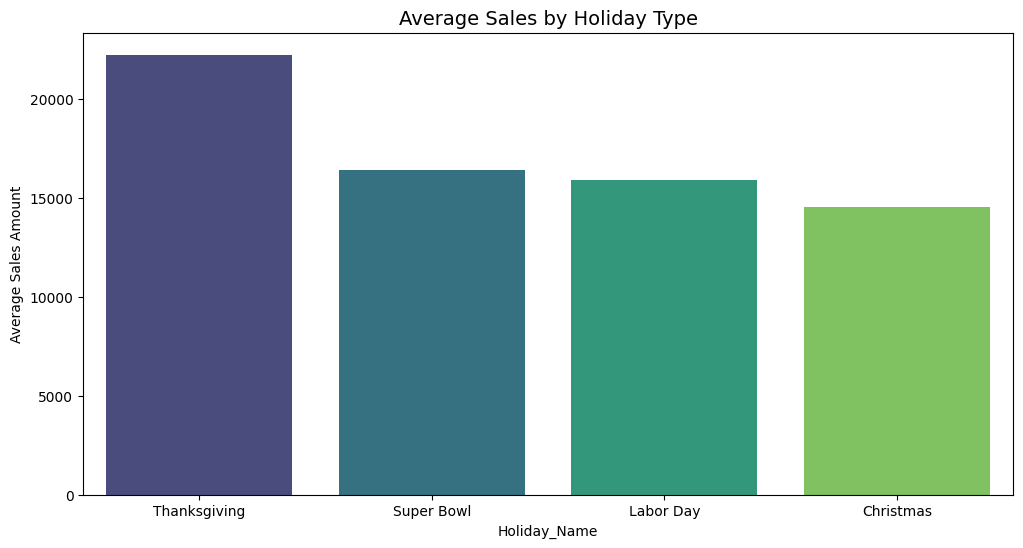

In [45]:
# 2. Define specific holiday dates based on competition rules
# Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13
# Labor Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13
# Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13
# Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

def get_holiday_name(row):
    if not row['IsHoliday']:
        return 'Non-Holiday'
    date_str = row['Date'].strftime('%Y-%m-%d')
    if date_str in ['2010-02-12', '2011-02-11', '2012-02-10']:
        return 'Super Bowl'
    elif date_str in ['2010-09-10', '2011-09-09', '2012-09-07']:
        return 'Labor Day'
    elif date_str in ['2010-11-26', '2011-11-25', '2012-11-23']:
        return 'Thanksgiving'
    elif date_str in ['2010-12-31', '2011-12-30', '2012-12-28']:
        return 'Christmas'
    else:
        return 'Other Holiday'

df_train['Holiday_Name'] = df_train.apply(get_holiday_name, axis=1)

# Calculate average sales by holiday type
holiday_type_sales = df_train[df_train['Holiday_Name'] != 'Non-Holiday'].groupby('Holiday_Name')['Weekly_Sales'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=holiday_type_sales, x='Holiday_Name', y='Weekly_Sales', palette='viridis')
plt.title('Average Sales by Holiday Type', fontsize=14)
plt.ylabel('Average Sales Amount')
plt.show()